<a href="https://colab.research.google.com/github/hottp2988/tibame-20251203/blob/main/winequality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 讀取資料 (檔案名為 winequality-red.csv)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

# 選擇前 6 項與第 12 項
features = df.columns[:6].tolist() + ['quality']
subset = df[features]
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


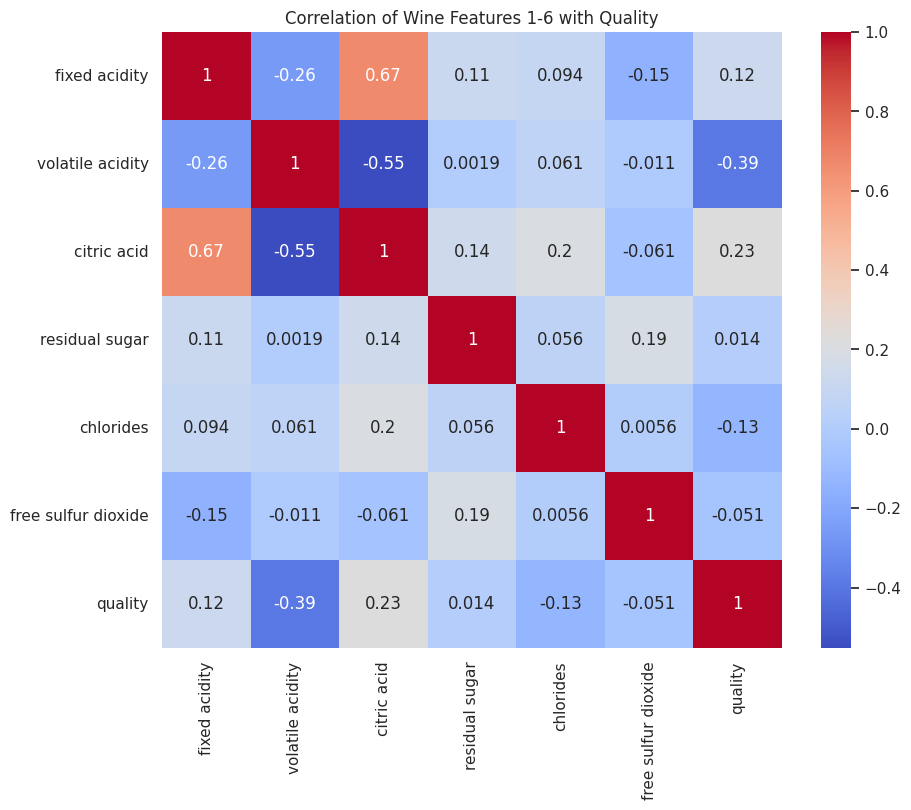

In [ ]:
# 繪製相關係數矩陣
plt.figure(figsize=(10, 8))
sns.heatmap(subset.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation of Wine Features 1-6 with Quality')
plt.show()


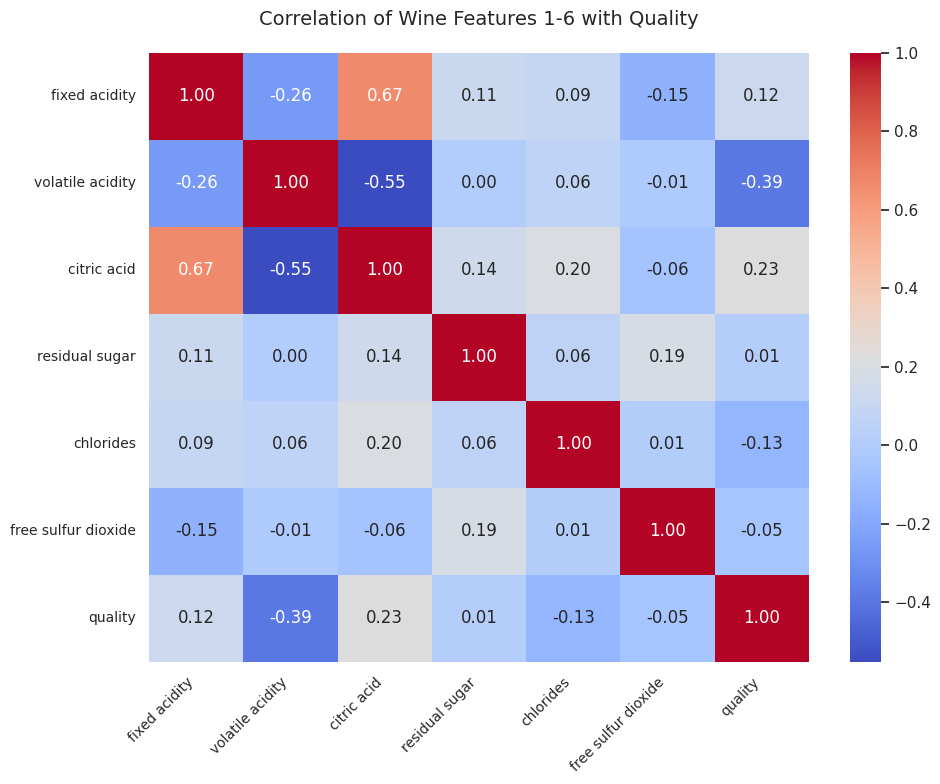

In [ ]:
# 選擇前 6 項與品質
features = df.columns[:6].tolist() + ['quality']
subset = df[features]

# 繪製相關係數矩陣 (熱力圖)
plt.figure(figsize=(10, 8))
corr = subset.corr()

# 繪製熱力圖
ax = sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

# --- 修改文字方向關鍵 ---
# rotation=45 代表旋轉 45 度，ha='right' 讓文字對齊右側比較美觀
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10) # y 軸保持水平 (0度)

plt.title('Correlation of Wine Features 1-6 with Quality', fontsize=14, pad=20)
plt.tight_layout() # 自動調整佈局避免文字被切掉
plt.show()

--- 模型評估結果 ---
均方誤差 (MSE): 0.5210 (越小越好)
判定係數 (R-squared): 0.2028 (越接近 1 代表模型解釋力越強)


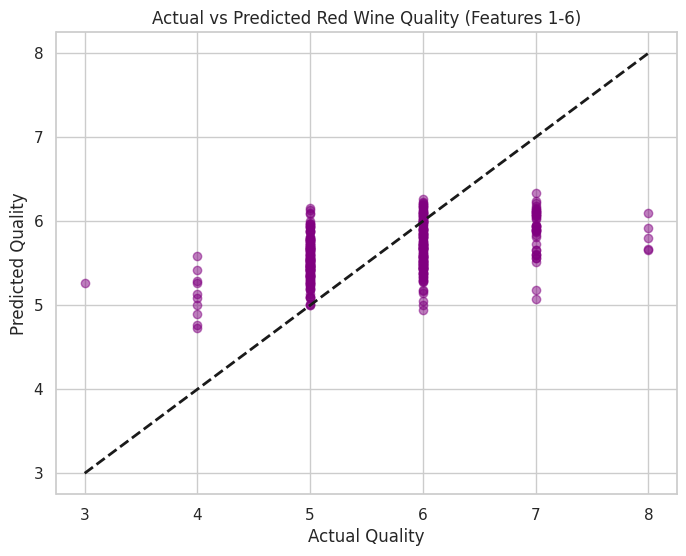

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. 準備數據 (X 為特徵, y 為目標值)
# 我們只選用 1-6 項作為預測變數
features_list = df.columns[:6].tolist()
X = df[features_list]
y = df['quality']

# 2. 分割資料集 (80% 訓練, 20% 測試)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 建立並訓練線性回歸模型
model = LinearRegression()
model.fit(X_train, y_train)

# 4. 進行預測
y_pred = model.predict(X_test)

# 5. 模型評估 (Model Evaluation)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- 模型評估結果 ---")
print(f"均方誤差 (MSE): {mse:.4f} (越小越好)")
print(f"判定係數 (R-squared): {r2:.4f} (越接近 1 代表模型解釋力越強)")

# 6. 視覺化：預測值 vs 實際值
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.title('Actual vs Predicted Red Wine Quality (Features 1-6)')
plt.show()

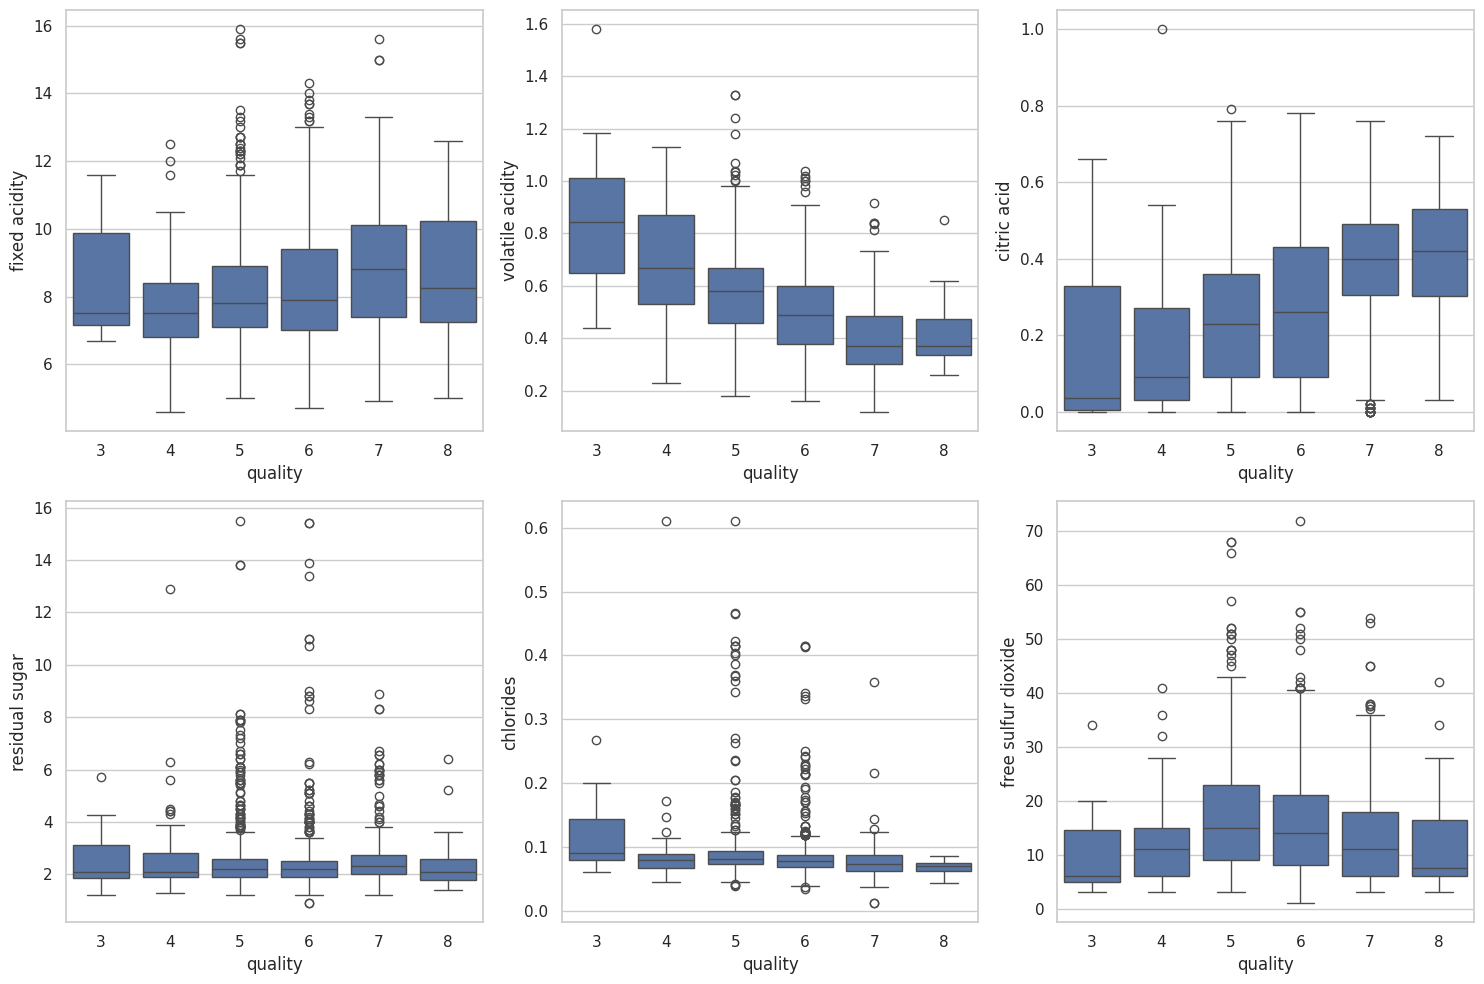

In [ ]:
# 繪製箱型圖觀察趨勢
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, col in enumerate(features[:-1]):
    sns.boxplot(x='quality', y=col, data=subset, ax=axes[i//3, i%3])
plt.tight_layout()
plt.show()

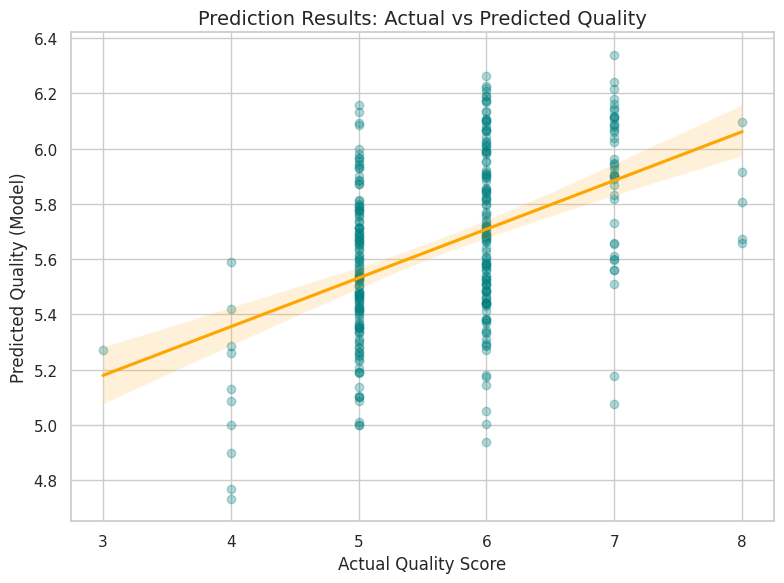

--- 模型績效分析 ---
R-squared (解釋力): 0.203
Mean Squared Error: 0.521


In [ ]:
# --- 【第二部分：模型預測與連動】 ---
X = data_subset[features_cols]
y = data_subset[target_col]

# 切分數據 (80% 訓練, 20% 測試)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 建立線性回歸模型
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# --- 【第三部分：預測結果視覺化】 ---
plt.figure(figsize=(8, 6))
# 使用 regplot 繪製趨勢線，x_jitter 能讓點不要全部疊在一起
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'orange'})

plt.title('Prediction Results: Actual vs Predicted Quality', fontsize=14)
plt.xlabel('Actual Quality Score')
plt.ylabel('Predicted Quality (Model)')
plt.tight_layout()
plt.show() # 第二張圖產出

# 輸出量化指標
print(f"--- 模型績效分析 ---")
print(f"R-squared (解釋力): {r2_score(y_test, y_pred):.3f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.3f}")

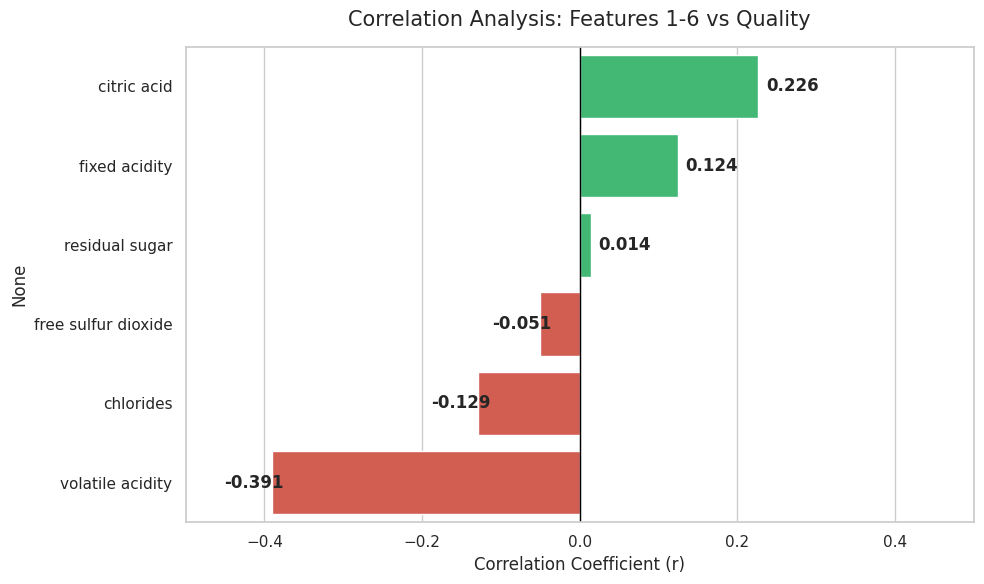

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 2. 篩選出 1-6 項 (特徵) 與 第 12 項 (品質)
features_cols = df.columns[:6].tolist()
target_col = 'quality'
data_subset = df[features_cols + [target_col]]

# --- 【第一部分：專業相關性分析圖】 ---
sns.set_theme(style="whitegrid") # 設定專業風格
plt.figure(figsize=(10, 6))

# 計算相關性並排序
correlations = data_subset.corr()[target_col].drop(target_col).sort_values(ascending=False)

# 繪製條形圖 (正相關綠色，負相關紅色)
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in correlations.values]
sns.barplot(
    x=correlations.values,
    y=correlations.index,
    hue=correlations.index,  # 明確指定根據 y 軸的特徵名稱來上色
    palette=colors,
    legend=False             # 隱藏不需要的圖例
)
plt.axvline(0, color='black', lw=1)
plt.title('Correlation Analysis: Features 1-6 vs Quality', fontsize=15, pad=15)
plt.xlabel('Correlation Coefficient (r)')
plt.xlim(-0.5, 0.5)

# 在圖表上標註數值
for i, v in enumerate(correlations.values):
    plt.text(v + (0.01 if v > 0 else -0.06), i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show() # 第一張圖產出

